In [ ]:
!pip install shap xgboost

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model, Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Research Yield Prediction"
DATA_DIR = os.path.join(BASE_DIR, "data/data/raw")
CSV_PATH = os.path.join(BASE_DIR, "data/data/metadata.csv")
MODEL_DIR = os.path.join(BASE_DIR, "models")

IMG_SIZE = 300
BATCH_SIZE = 16
EPOCHS = 60

os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"[INFO] Seed set to {seed}")


def load_image(img_path):
    if not os.path.exists(img_path):
        return None
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img

def extract_multi_angle_features(image_paths):
    features = []
    for path in image_paths:
        img = load_image(path)
        if img is None:
            continue
        img_feat = effnet.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )
        features.append(img_feat[0])
    if len(features) == 0:
        raise ValueError("No valid images provided")
    # stack features
    features = np.vstack(features)
    # average features from multiple angles
    combined_features = np.mean(features, axis=0, keepdims=True)

    return combined_features

def load_dataset(data_dir, csv_path):
    df = pd.read_csv(csv_path)
    df['full_path'] = df['image_path'].apply(lambda x: os.path.join(data_dir, x))
    df = df[df['full_path'].apply(os.path.exists)].reset_index(drop=True)
    return df

def extract_dl_features(model, image_paths):

    images = []
    valid_indices = []

    for idx, path in enumerate(image_paths):
        img = load_image(path)
        if img is not None:
            images.append(img)
            valid_indices.append(idx)

    if len(images) == 0:
        return np.array([]), []

    images = np.array(images)

    features = model.predict(images, verbose=1)

    return features, valid_indices

def get_data_generators(df):

    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42
    )

    train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    shear_range=0.15
)

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    def custom_generator(dataframe):

        while True:

            for i in range(0, len(dataframe), BATCH_SIZE):

                batch_df = dataframe.iloc[i:i+BATCH_SIZE]

                batch_images = []

                for path in batch_df['full_path']:
                    img = tf.keras.utils.load_img(
                        path,
                        target_size=(IMG_SIZE, IMG_SIZE)
                    )
                    img = tf.keras.utils.img_to_array(img)
                    batch_images.append(img)

                batch_images = np.array(batch_images)
                batch_images = train_datagen.standardize(batch_images)

                batch_tab = batch_df[['soil_moisture', 'temperature']].values / 100.0
                batch_y = batch_df['yield_kg'].values

                yield ({"image_input": batch_images,
                        "tabular_input": batch_tab}, batch_y)

    train_gen = custom_generator(train_df)
    val_gen = custom_generator(val_df)

    return train_gen, val_gen, len(train_df), len(val_df), val_df


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

def train_xgboost():

    print("[INFO] Training Optimized XGBoost with PCA + Scaling + Regularization...")

    df = load_dataset(DATA_DIR, CSV_PATH)

    df["moisture_temp_ratio"] = df["soil_moisture"] / (df["temperature"] + 1)
    df["moisture_squared"] = df["soil_moisture"] ** 2
    df["temp_squared"] = df["temperature"] ** 2


    image_features, valid_indices = extract_dl_features(
        effnet,
        df['full_path'].tolist()
    )

    df = df.iloc[valid_indices].reset_index(drop=True)

    tabular_features = df[
        ["soil_moisture", "temperature",
         "moisture_temp_ratio",
         "moisture_squared",
         "temp_squared"]
    ].values

    y = df["yield_kg"].values

    X_train_img, X_test_img, X_train_tab, X_test_tab, y_train, y_test = train_test_split(
        image_features,
        tabular_features,
        y,
        test_size=0.2,
        random_state=42
    )
    scaler = StandardScaler()
    X_train_tab_scaled = scaler.fit_transform(X_train_tab)
    X_test_tab_scaled = scaler.transform(X_test_tab)

    print("\nFirst 5 Scaled Tabular Rows:")
    print(X_train_tab_scaled[:5])

    print("[INFO] Applying PCA...")
    pca = PCA(n_components=min(100, X_train_img.shape[1]))

    X_train_img_reduced = pca.fit_transform(X_train_img)
    X_test_img_reduced = pca.transform(X_test_img)

    X_train = np.concatenate([X_train_img_reduced, X_train_tab_scaled], axis=1)
    X_test = np.concatenate([X_test_img_reduced, X_test_tab_scaled], axis=1)

    xgb = XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        n_jobs=1
    )

    xgb.fit(
    X_train,
    y_train)

    xgb.save_model(os.path.join(MODEL_DIR, "xgb_optimized.json"))

    train_r2 = r2_score(y_train, xgb.predict(X_train))
    test_r2 = r2_score(y_test, xgb.predict(X_test))

    print("\n📊 Performance:")
    print("Train R2:", train_r2)
    print("Test  R2:", test_r2)

    return xgb, X_train, X_test, y_train, y_test, pca, scaler


def build_finetune_model():

    effnet = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    for layer in effnet.layers[:-20]:
        layer.trainable = False

    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
    x = effnet(img_input)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)

    tab_input = layers.Input(shape=(2,), name="tabular_input")
    t = layers.Dense(16, activation="relu")(tab_input)
    t = layers.Dense(8, activation="relu")(t)
    combined = layers.concatenate([x, t])

    combined = layers.concatenate([x, t])
    z = layers.Dense(64, activation='relu')(combined)
    output = layers.Dense(1, name="yield_output")(z)

    model = models.Model(
        inputs=[img_input, tab_input],
        outputs=output
    )

    model.compile(
        optimizer=optimizers.Adam(1e-4),
        loss='mse',
        metrics=['mae']
    )

    return model

def train_finetune():

    set_seed(42)

    df = load_dataset(DATA_DIR, CSV_PATH)

    train_gen, val_gen, n_train, n_val, val_df = get_data_generators(df)

    model = build_finetune_model()

    model.fit(
        train_gen,
        validation_data=val_gen,
        steps_per_epoch=n_train // BATCH_SIZE,
        validation_steps=n_val // BATCH_SIZE,
        epochs=EPOCHS
    )

    model.save(os.path.join(MODEL_DIR, "yield_finetuned.h5"))

    return model

class YieldPredictor:

    def __init__(self, xgb_path=None):

        self.xgb_model = None

        if xgb_path and os.path.exists(xgb_path):
            self.xgb_model = XGBRegressor()
            self.xgb_model.load_model(xgb_path)

        self.effnet = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            pooling='avg'
        )

    def predict_xgb(self, img_path, soil, temp):

        img = load_image(img_path)

        img_feats = self.effnet.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )

        X = np.concatenate([img_feats, [[soil, temp]]], axis=1)

        return float(self.xgb_model.predict(X)[0])


def make_gradcam_heatmap(input_data, model, last_conv_layer_name):

    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output,
                 model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(input_data)
        loss = preds[:, 0]

    grads = tape.gradient(loss, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = last_conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

def run_explanations(model_path, img_path, soil, temp):

    model = load_model(model_path, compile=False)

    img = load_image(img_path)
    img_input = np.expand_dims(img, axis=0)
    tab_input = np.array([[soil/100.0, temp/100.0]])

    heatmap = make_gradcam_heatmap(
        [img_input, tab_input],
        model,
        model.layers[1].name
    )

    jet_heatmap = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    )

    original_img = cv2.imread(img_path)
    original_img = cv2.resize(original_img, (IMG_SIZE, IMG_SIZE))

    superimposed = jet_heatmap * 0.4 + original_img

    save_path = os.path.join(BASE_DIR, "last_gradcam.jpg")
    cv2.imwrite(save_path, superimposed)

    print(f"[INFO] Grad-CAM saved at {save_path}")

In [ ]:
df = load_dataset(DATA_DIR, CSV_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (376, 6)


,plant_id,image_path,soil_moisture,temperature,yield_kg,full_path
0,plant_001,plant_001/IMG_8454.JPG,60.337007,28.887561,0.782319,/content/drive/MyDrive/Research Yield Predicti...
1,plant_001,plant_001/IMG_8450.JPG,60.337007,28.887561,0.782319,/content/drive/MyDrive/Research Yield Predicti...
2,plant_001,plant_001/IMG_8449.JPG,60.337007,28.887561,0.782319,/content/drive/MyDrive/Research Yield Predicti...
3,plant_001,plant_001/IMG_8453.JPG,60.337007,28.887561,0.782319,/content/drive/MyDrive/Research Yield Predicti...
4,plant_001,plant_001/IMG_8452.JPG,60.337007,28.887561,0.782319,/content/drive/MyDrive/Research Yield Predicti...


In [ ]:
# @title
# Initialize effnet globally for prediction function before training XGBoost
effnet = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg'
)

xgb_model, X_train, X_test, y_train, y_test, pca, scaler = train_xgboost()

[INFO] Training Optimized XGBoost with PCA + Scaling + Regularization...
12/12 ━━━━━━━━━━━━━━━━━━━━ 61s 5s/step

First 5 Scaled Tabular Rows:
[[ 1.04132546 -0.31305829  1.14187805  1.02765922 -0.37125352]
 [-1.00546174 -1.30003384 -0.42587099 -0.98126966 -1.25720143]
 [ 1.45806906 -1.49089828  2.52882491  1.55886845 -1.41411029]
 [ 1.3942203   0.11575638  1.20584977  1.47480122  0.05260574]
 [ 0.09427604  1.51722463 -0.57593194 -0.02581366  1.60239579]]
[INFO] Applying PCA...

📊 Performance:
Train R2: 0.9993116178939212
Test  R2: 0.6386189139889695


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    plt.show()

    return y_pred

MAE : 0.16979761236220478
RMSE: 0.20900935422040665
R2  : 0.6386189139889695


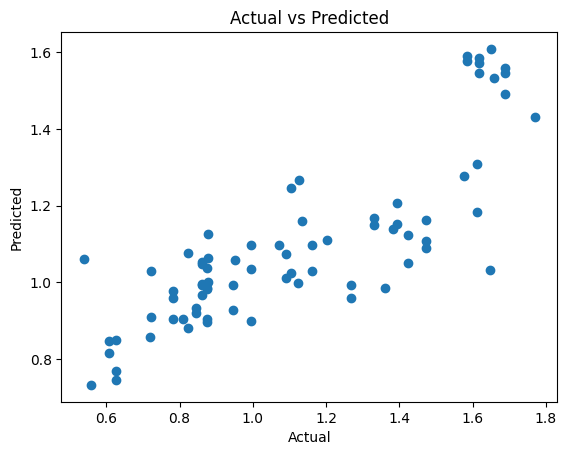

array([1.5766975 , 0.95973146, 0.9987324 , 1.0243037 , 0.933283  ,
       1.0961527 , 0.85893506, 0.92718035, 0.9924054 , 0.8503358 ,
       1.3073795 , 1.2064579 , 1.0016563 , 0.7447886 , 1.5886453 ,
       0.8967047 , 0.7330592 , 0.9093816 , 0.8167274 , 0.9050905 ,
       1.1587673 , 0.92113113, 1.0573328 , 0.9059194 , 1.0776683 ,
       0.9967044 , 1.1681151 , 1.090479  , 0.98553276, 1.1090882 ,
       1.584283  , 1.2450448 , 0.9666417 , 1.5583686 , 1.6080295 ,
       1.1251682 , 1.4914438 , 1.0289477 , 1.5319616 , 1.0615538 ,
       1.5725067 , 1.1505096 , 1.0980889 , 0.9841377 , 1.0476938 ,
       1.1509516 , 1.0624801 , 1.0970516 , 0.9941294 , 1.0313611 ,
       1.4307877 , 1.030546  , 1.1624029 , 0.95904225, 1.0364034 ,
       1.5454086 , 0.9864163 , 0.90060663, 0.9924082 , 1.54638   ,
       1.2674029 , 1.0120189 , 0.90543014, 0.97808444, 0.7695117 ,
       1.2769649 , 1.0516832 , 1.139186  , 1.1839917 , 1.0543338 ,
       1.11156   , 0.8814654 , 0.8481454 , 1.0729775 , 1.12267

In [ ]:
evaluate_model(xgb_model, X_test, y_test)

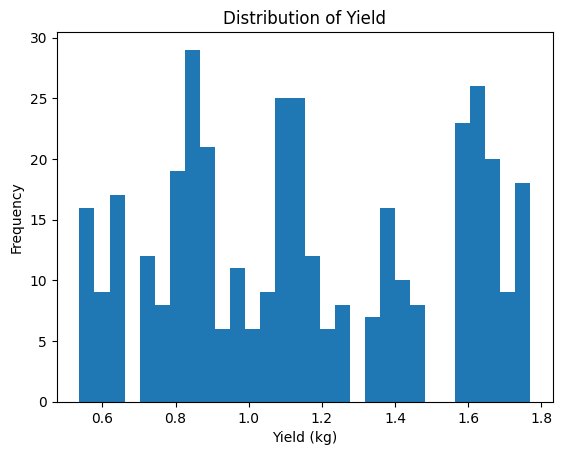

In [ ]:
plt.figure()
plt.hist(df['yield_kg'], bins=30)
plt.title("Distribution of Yield")
plt.xlabel("Yield (kg)")
plt.ylabel("Frequency")
plt.show()

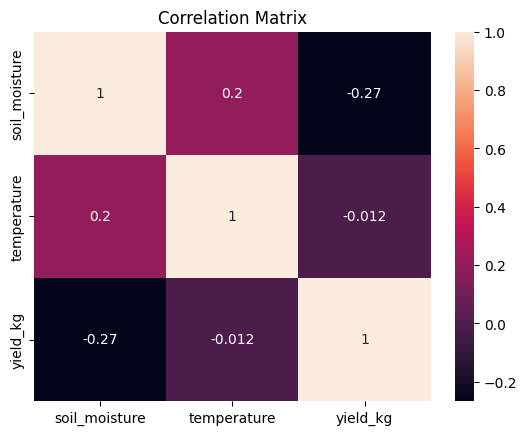

In [ ]:
import seaborn as sns

corr = df[['soil_moisture', 'temperature', 'yield_kg']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

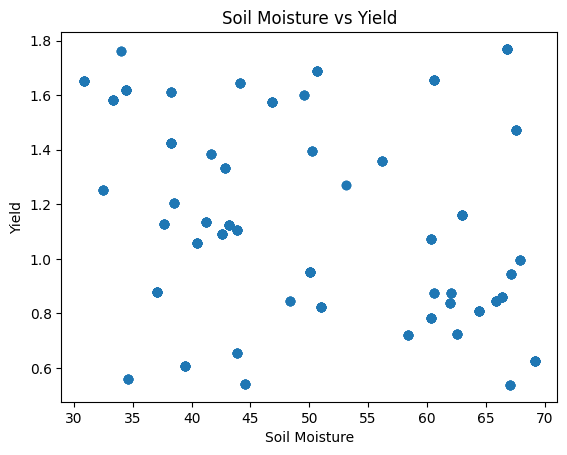

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["soil_moisture"], df["yield_kg"])
plt.xlabel("Soil Moisture")
plt.ylabel("Yield")
plt.title("Soil Moisture vs Yield")
plt.show()

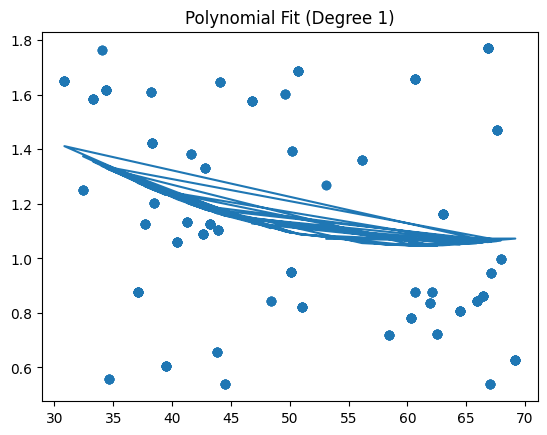

In [ ]:
import numpy as np

z = np.polyfit(df["soil_moisture"], df["yield_kg"], 2)
p = np.poly1d(z)

plt.figure()
plt.scatter(df["soil_moisture"], df["yield_kg"])
plt.plot(df["soil_moisture"], p(df["soil_moisture"]))
plt.title("Polynomial Fit (Degree 1)")
plt.show()

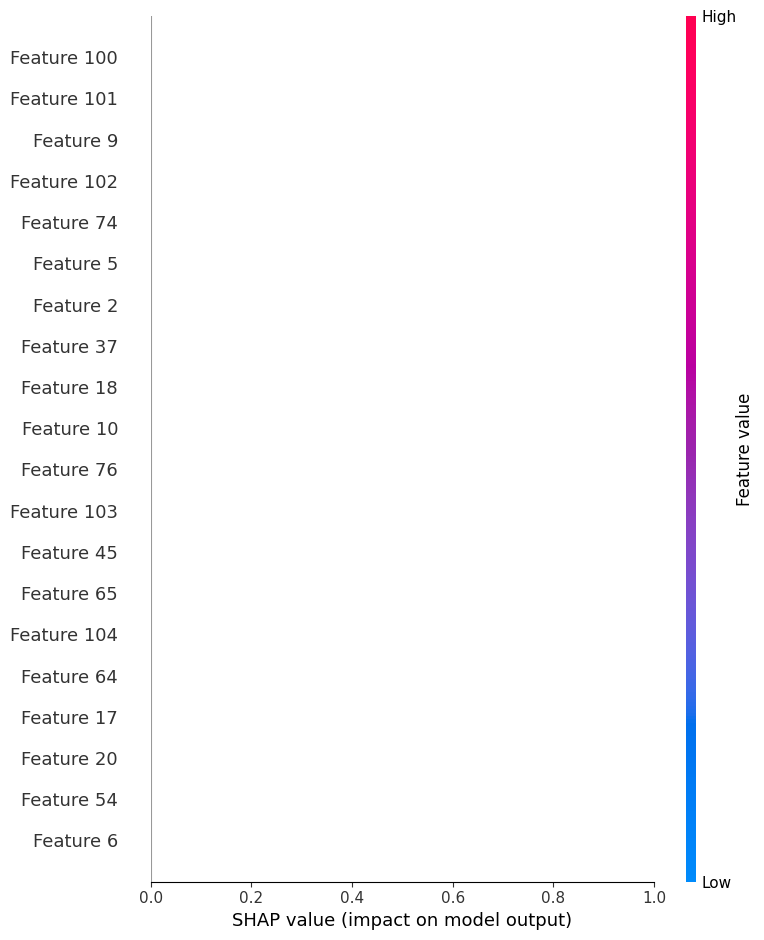

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="dependence")

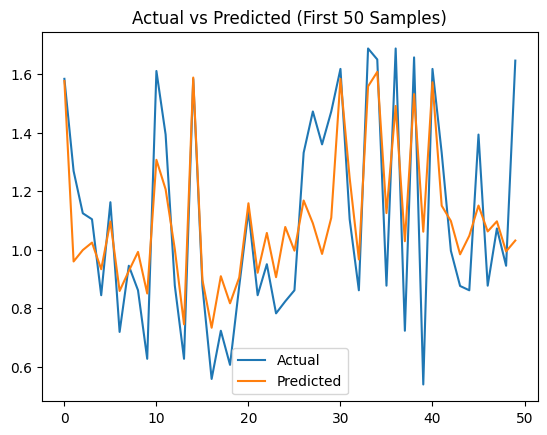

In [ ]:
y_pred = xgb_model.predict(X_test)

plt.figure()
plt.plot(y_test[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 50 Samples)")
plt.show()

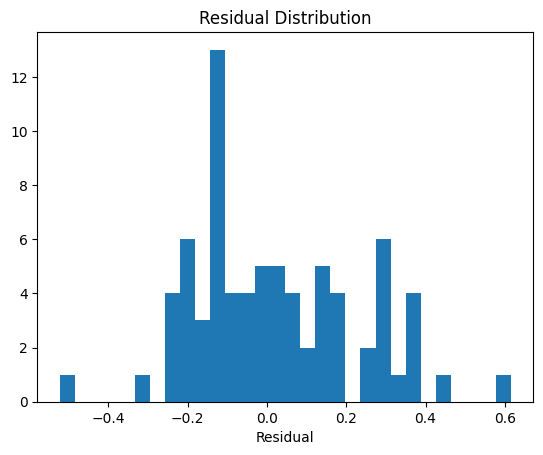

In [ ]:
residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

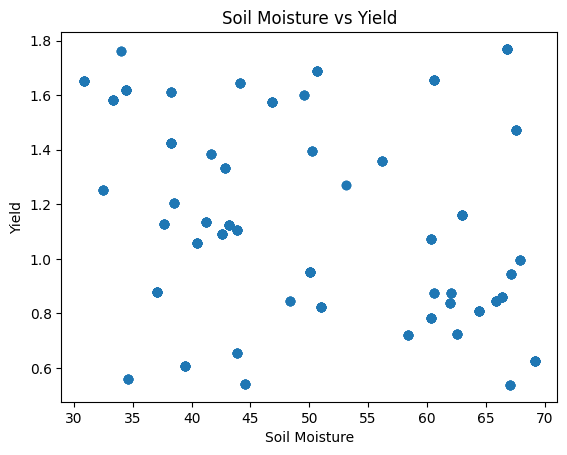

In [ ]:
plt.figure()
plt.scatter(df['soil_moisture'], df['yield_kg'])
plt.xlabel("Soil Moisture")
plt.ylabel("Yield")
plt.title("Soil Moisture vs Yield")
plt.show()

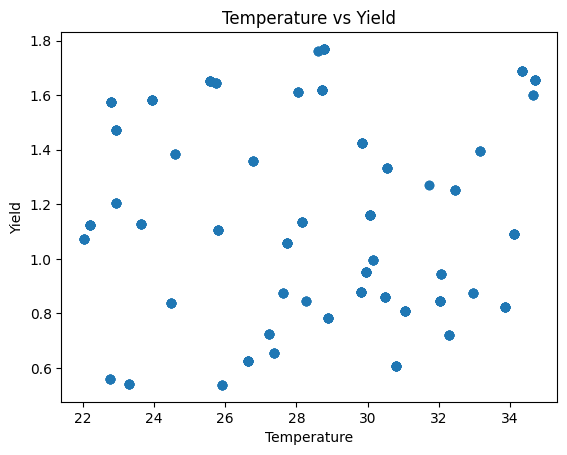

In [ ]:
plt.figure()
plt.scatter(df['temperature'], df['yield_kg'])
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.title("Temperature vs Yield")
plt.show()

In [ ]:
import shap

def explain_shap(model, X_sample):

    print("🔎 Creating SHAP Explainer...")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)

    print("📊 SHAP Summary Plot")
    shap.summary_plot(shap_values, X_sample)

    print("📊 SHAP Feature Importance")
    shap.plots.bar(shap_values)

🔎 Creating SHAP Explainer...
📊 SHAP Summary Plot


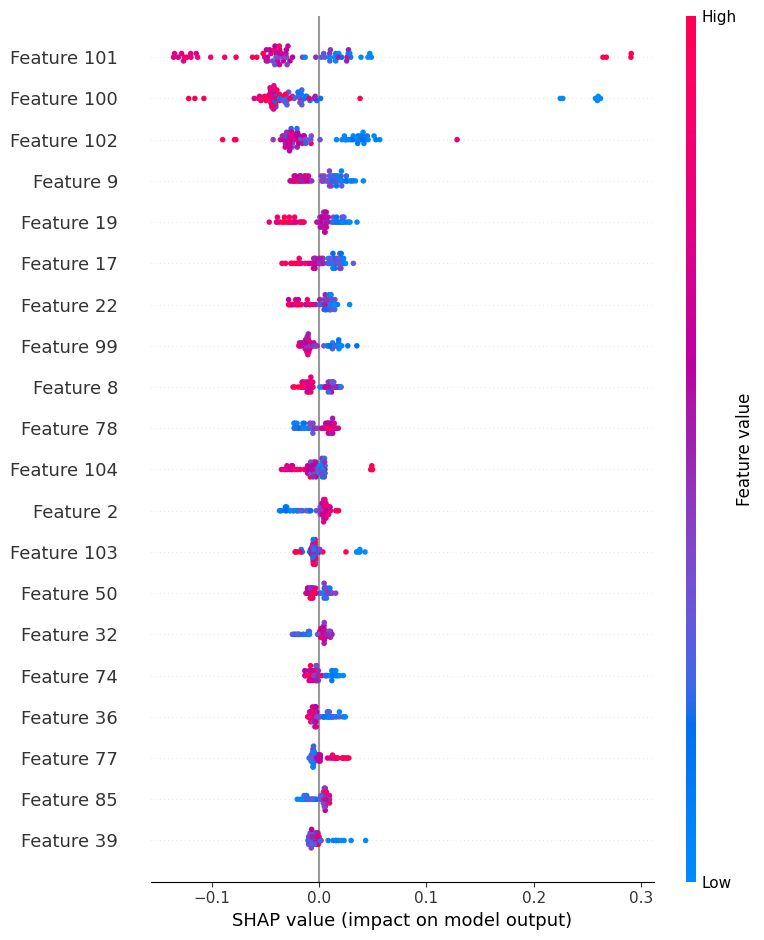

📊 SHAP Feature Importance


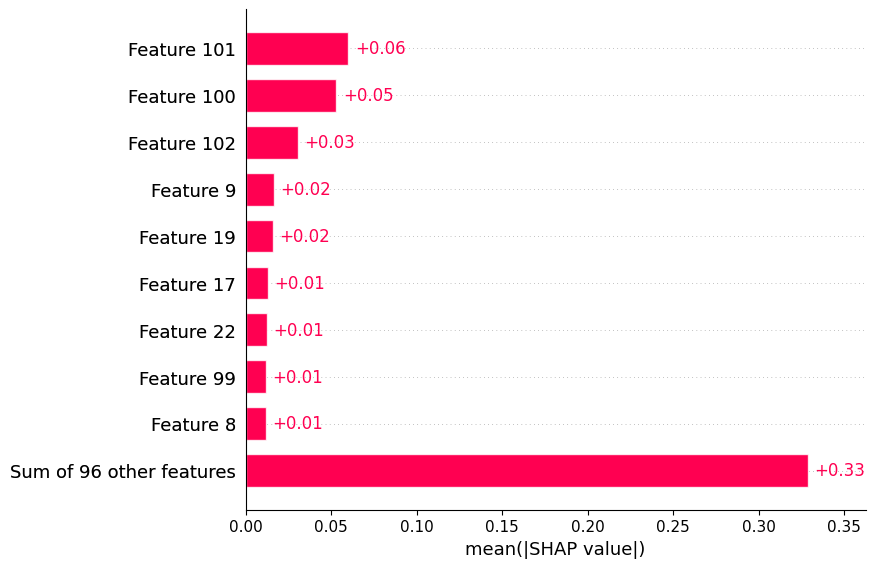

In [ ]:
explain_shap(xgb_model, X_test[:100])

In [ ]:
importances = xgb_model.feature_importances_

tabular_importance = importances[-2:]
print("Soil Moisture Importance:", tabular_importance[0])
print("Temperature Importance:", tabular_importance[1])

Soil Moisture Importance: 0.06617659
Temperature Importance: 0.051787


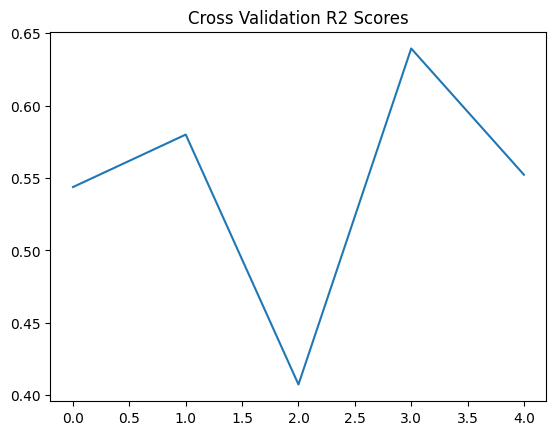

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=False)
scores = cross_val_score(xgb_model, X_train, y_train, scoring='r2', cv=kf)

plt.figure()
plt.plot(scores)
plt.title("Cross Validation R2 Scores")
plt.show()

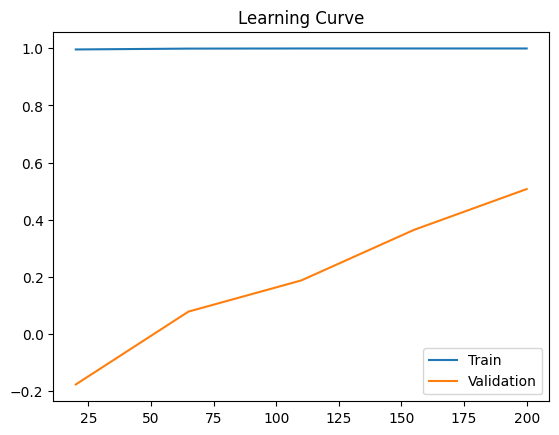

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(xgb_model, X_train, y_train, cv=3)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.show()

In [ ]:
def generate_xai_insights(model, X_sample, feature_names):

    import shap
    import numpy as np

    print("🔎 Generating XAI Insights...\n")

    # Create SHAP explainer
    explainer = shap.Explainer(model)
    shap_values = explainer(X_sample)

    # Mean absolute SHAP values
    mean_shap = np.abs(shap_values.values).mean(axis=0)

    # Use provided feature_names instead of X_sample.columns
    feature_importance = list(zip(feature_names, mean_shap))
    feature_importance.sort(key=lambda x: x[1], reverse=True)

    print("📊 Top 5 Most Influential Features:\n")

    for feature, value in feature_importance[:5]:
        print(f"- {feature} (mean impact: {value:.4f})")

    print("\n🧠 Interpretation:\n")

    top_features = [f[0] for f in feature_importance[:5]]

    # Check if tabular features are important
    if "soil_moisture" in top_features:
        print("• Soil moisture significantly influences yield prediction.")
        print("  Higher soil moisture values generally increase predicted yield.\n")

    if "temperature" in top_features:
        print("• Temperature plays a strong role in determining yield.")
        print("  The model adjusts predictions based on environmental temperature.\n")

    print("• Image-based CNN features contribute substantially to the model.")
    print("  This suggests that plant visual characteristics strongly impact yield estimation.\n")

    print("📌 Overall Model Behavior:")
    print("The model integrates both visual plant traits and environmental variables")
    print("to estimate crop yield. Feature interactions suggest that optimal")
    print("environmental conditions combined with healthy plant structure")
    print("lead to higher predicted yields.")

In [ ]:
pca_feature_names = [f"pca_{i}" for i in range(pca.n_components)]
feature_names = (
    [f"pca_{i}" for i in range(pca.n_components_)] +
    ["soil_moisture","temperature",
     "moisture_temp_ratio","moisture_squared","temp_squared"]
)
tabular_feature_names = ["soil_moisture", "temperature", "moisture_temp_ratio", "moisture_squared", "temp_squared"]
all_feature_names = pca_feature_names + tabular_feature_names

generate_xai_insights(xgb_model, X_test[:200], all_feature_names)

🔎 Generating XAI Insights...

📊 Top 5 Most Influential Features:

- temperature (mean impact: 0.0645)
- soil_moisture (mean impact: 0.0537)
- moisture_temp_ratio (mean impact: 0.0291)
- pca_19 (mean impact: 0.0176)
- pca_9 (mean impact: 0.0152)

🧠 Interpretation:

• Soil moisture significantly influences yield prediction.
  Higher soil moisture values generally increase predicted yield.

• Temperature plays a strong role in determining yield.
  The model adjusts predictions based on environmental temperature.

• Image-based CNN features contribute substantially to the model.
  This suggests that plant visual characteristics strongly impact yield estimation.

📌 Overall Model Behavior:
The model integrates both visual plant traits and environmental variables
to estimate crop yield. Feature interactions suggest that optimal
environmental conditions combined with healthy plant structure
lead to higher predicted yields.


In [ ]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(xgb_model, X_train, y_train, scoring='r2', cv=kf)

print("Cross-Validation R2 scores:", scores)
print("Mean CV R2:", scores.mean())

Cross-Validation R2 scores: [0.57334068 0.48556604 0.43624061 0.52402113 0.57852144]
Mean CV R2: 0.5195379802456512


In [ ]:
# baseline model
def train_baseline_xgb():

    print("[INFO] Training Baseline XGBoost...")

    df = load_dataset(DATA_DIR, CSV_PATH)

    # Extract CNN features (NO PCA, NO feature engineering)
    effnet = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling='avg'
    )

    image_features, valid_indices = extract_dl_features(
        effnet,
        df['full_path'].tolist()
    )

    df = df.iloc[valid_indices].reset_index(drop=True)

    X = np.concatenate([
        image_features,
        df[['soil_moisture','temperature']].values
    ], axis=1)

    y = df['yield_kg'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        n_jobs=1
    )

    xgb.fit(X_train, y_train)

    y_pred = xgb.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    MODEL_RMSE = rmse
    MEAN_YIELD = np.mean(y_train)

    print("\nBaseline Performance:")
    print("MAE :", mae)
    print("RMSE:", MODEL_RMSE)
    print("Mean Yield:", MEAN_YIELD)
    print("R2  :", r2)

    return r2, rmse, mae

In [ ]:
#train both models
baseline_r2, baseline_rmse, baseline_mae = train_baseline_xgb()

MODEL_RMSE = baseline_rmse
MEAN_YIELD = np.mean(y_train)

xgb_model, X_train, X_test, y_train, y_test, pca, scaler = train_xgboost()

y_pred_opt = xgb_model.predict(X_test)

opt_r2 = r2_score(y_test, y_pred_opt)
opt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_opt))
opt_mae = mean_absolute_error(y_test, y_pred_opt)

print("\nOptimized Performance:")
print("MAE :", opt_mae)
print("RMSE:", opt_rmse)
print("R2  :", opt_r2)
# store metrics for API confidence calculation
MODEL_RMSE = opt_rmse
MEAN_YIELD = np.mean(y_train)

[INFO] Training Baseline XGBoost...
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step

Baseline Performance:
MAE : 0.1905169456224669
RMSE: 0.23903336561326596
Mean Yield: 1.1595359009150554
R2  : 0.5273376338414639
[INFO] Training Optimized XGBoost with PCA + Scaling + Regularization...
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step

First 5 Scaled Tabular Rows:
[[ 1.04132546 -0.31305829  1.14187805  1.02765922 -0.37125352]
 [-1.00546174 -1.30003384 -0.42587099 -0.98126966 -1.25720143]
 [ 1.45806906 -1.49089828  2.52882491  1.55886845 -1.41411029]
 [ 1.3942203   0.11575638  1.20584977  1.47480122  0.05260574]
 [ 0.09427604  1.51722463 -0.57593194 -0.02581366  1.60239579]]
[INFO] Applying PCA...

📊 Performance:
Train R2: 0.999267022406088
Test  R2: 0.6838668741359331

Optimized Performance:
MAE : 0.15182495408759364
RMSE: 0.19548706076623631
R2  : 0.6838668741359331


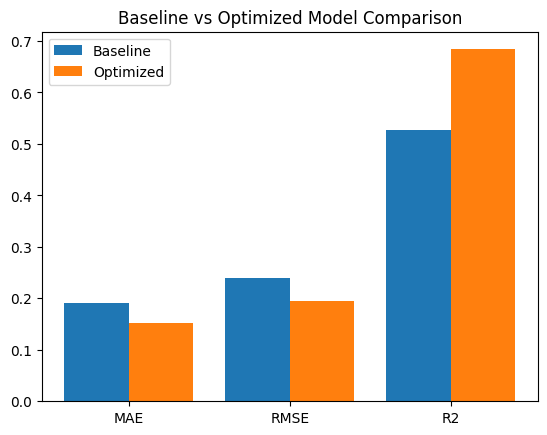

In [ ]:
#plot comparison
labels = ['MAE', 'RMSE', 'R2']

baseline_values = [baseline_mae, baseline_rmse, baseline_r2]
optimized_values = [opt_mae, opt_rmse, opt_r2]

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, baseline_values, width=0.4, label='Baseline')
plt.bar(x + 0.2, optimized_values, width=0.4, label='Optimized')

plt.xticks(x, labels)
plt.legend()
plt.title("Baseline vs Optimized Model Comparison")
plt.show()

In [ ]:
# test model with manual input
def predict_new_sample(image_paths, soil, temp):

    # Feature engineering
    moisture_temp_ratio = soil / (temp + 1)
    moisture_squared = soil ** 2
    temp_squared = temp ** 2

    # Multi-angle feature extraction
    img_feat = extract_multi_angle_features(image_paths)

    # Apply PCA
    img_feat_reduced = pca.transform(img_feat)

    tab_features = np.array([[soil,
                              temp,
                              moisture_temp_ratio,
                              moisture_squared,
                              temp_squared]])

    # scale tabular features
    tab_scaled = scaler.transform(tab_features)

    X_new = np.concatenate([img_feat_reduced, tab_scaled], axis=1)

    prediction = xgb_model.predict(X_new)

    return float(prediction[0])

In [ ]:
#test with real values
sample_images = [
    df['full_path'].iloc[0],
    df['full_path'].iloc[1],
    df['full_path'].iloc[2]
]

predicted_yield = predict_new_sample(
    sample_images,
    soil=60,
    temp=28
)

print("Predicted Yield:", predicted_yield)

Predicted Yield: 0.9581333994865417


In [ ]:
#with different values
predict_new_sample(sample_images, soil=80, temp=25)
predict_new_sample(sample_images, soil=40, temp=32)

0.9304777383804321

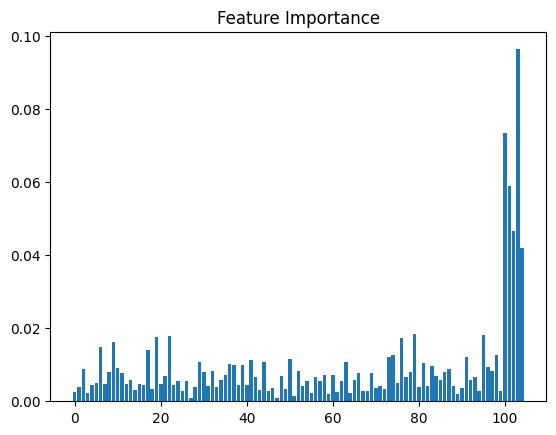

In [ ]:
plt.figure()
plt.bar(range(len(xgb_model.feature_importances_)), xgb_model.feature_importances_)
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib

# create metrics
metrics = {
    "rmse": MODEL_RMSE,
    "mean_yield": MEAN_YIELD
}

# save models
xgb_model.save_model(os.path.join(MODEL_DIR,"xgb_model.json"))
joblib.dump(pca, os.path.join(MODEL_DIR,"pca.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR,"scaler.pkl"))
joblib.dump(metrics, os.path.join(MODEL_DIR,"metrics.pkl"))

['/content/drive/MyDrive/Research Yield Prediction/models/metrics.pkl']

In [ ]:
def prediction_confidence(prediction):
    error_ratio = MODEL_RMSE / MEAN_YIELD
    confidence = max(0, 1 - error_ratio)
    return round(confidence * 100, 2)

In [ ]:
predicted_yield = predict_new_sample(
    sample_images,
    soil=60,
    temp=28
)

conf = prediction_confidence(predicted_yield)

print("Predicted Yield:", predicted_yield)
print("Prediction Confidence:", conf, "%")

In [ ]:
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual vs Prediction")
plt.show()